# Profile plots of DCM labels

This notebook builds profile plots of DCM labels. 

## Input

- DCM scores per gene bin, available from GEO (GSE304236_DCM.bins.txt)
- RNA expression in TPM, available from GEO (GSE304232_iPSCs.RNA-seq.TPMs.txt)

## Output

- Figure 1e. Profile plot iPSC +dox with RNA-seq categories
- Figure S2c. Profile plot iPSC -dox with RNA-seq categories
- Figure S2e. Profile plots of iPSC -dox and DCM-NLS
- Figure S2f. Correlation between DCM-POLR2B and DCM-NLS profiles
- Figure S3c: Profile plots of iPSC propagation experiment
- Figure S4d: Profile plots of PGT differentiation experiment
- Figure 2b: TSS enrichment in PGT differentiation experiment

## Packages

In [1]:
# General
from pathlib import Path
import numpy as np
import pandas as pd

# Plotting
import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

# Statistics
import scipy
from statsmodels.stats.multitest import multipletests

# Plot settings
plt.rcParams.update({"figure.figsize": (10, 10), "svg.fonttype": "none", "font.family": "Arial"})
sns.set_style("ticks")

In [2]:
# Directories: update these paths as needed
input_dir = "../Input/GEO"   # folder where GEO data is stored
output_dir = "../Output"    # folder where output files will be saved
Path(output_dir).mkdir(parents=True, exist_ok=True)

# Settings
level_colors = ["#95c1b6", "#5f8386", "#264653"]  # colors for profile plots
n_bins = 50

## Load counts per bin

In [3]:
bin_df = pd.read_csv(f"{input_dir}/GSE304236_DCM.bins.txt", sep="\t", index_col=False, header=0)
bin_df = bin_df[bin_df["Bin"].notna() & (bin_df["Bin"] != ".")]
bin_df["Bin"] = bin_df["Bin"].astype(int)

# Remove extreme bins
bin_df["Mean"] = bin_df[["iPSC_nodox", "iPSC_dox", "C6_nodox", "C6_dox", "DCM-NLS",
                  "T0", "T24", "T48", "T72", "iPSC_chase", "DE_chase", "DE_dox", "PGT_chase"]].mean(axis=1)
max_norm = bin_df["Mean"].sample(10000).quantile(0.999)
bin_df = bin_df[bin_df["Mean"] < max_norm]

display(bin_df)

/tmp/ipykernel_1975159/1833762399.py:1: DtypeWarning: Columns (3) have mixed types. Specify dtype option on import or set low_memory=False.
  bin_df = pd.read_csv(f"{input_dir}/GSE304236_DCM.bins.txt", sep="\t", index_col=False, header=0)


,Gene_bin,GeneName,GeneID,Bin,NrSites,iPSC_nodox,iPSC_dox,C6_nodox,C6_dox,DCM-NLS,T0,T24,T48,T72,iPSC_chase,DE_chase,DE_dox,PGT_chase,Mean
1,ENSG00000000003.1,TSPAN6,ENSG00000000003,1,1,0.000000,0.000000,0.000000,0.009132,0.0,0.0,0.0,0.0,0.0,0.000000,0.000000,0.000000,0.000000,0.000702
2,ENSG00000000003.10,TSPAN6,ENSG00000000003,10,1,0.000000,0.093232,0.000000,0.041593,0.0,0.0,0.0,0.0,0.0,0.000000,0.000000,0.086487,0.136260,0.027506
3,ENSG00000000003.100,TSPAN6,ENSG00000000003,100,1,0.000000,0.038349,0.000000,0.017751,0.0,0.0,0.0,0.0,0.0,0.055632,0.062818,0.012467,0.000000,0.014386
4,ENSG00000000003.101,TSPAN6,ENSG00000000003,101,2,0.009543,0.040529,0.014217,0.021053,0.0,0.0,0.0,0.0,0.0,0.051089,0.088612,0.047330,0.000000,0.020952
5,ENSG00000000003.104,TSPAN6,ENSG00000000003,104,1,0.000000,0.098173,0.000000,0.064921,0.0,0.0,0.0,0.0,0.0,0.000000,0.000000,0.034669,0.000000,0.015213
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3910760,ENSG00000291301.70,.,ENSG00000291301,70,1,0.007859,0.026296,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0,0.274883,0.062818,0.067972,0.068902,0.039133
3910761,ENSG00000291301.83,.,ENSG00000291301,83,2,0.000000,0.034532,0.000000,0.016487,0.0,0.0,0.0,0.0,0.0,0.000000,0.000000,0.023665,0.000000,0.005745
3910762,ENSG00000291301.87,.,ENSG00000291301,87,1,0.000000,0.000000,0.000000,0.036016,0.0,0.0,0.0,0.0,0.0,0.000000,0.000000,0.000000,0.000000,0.002770
3910763,ENSG00000291301.95,.,ENSG00000291301,95,1,0.000000,0.000000,0.000000,0.014709,0.0,0.0,0.0,0.0,0.0,0.000000,0.000000,0.000000,0.000000,0.001131


## Figure 1e. Profile plot iPSC +dox with RNA-seq categories

In [4]:
tpm = pd.read_csv(f"{input_dir}/GSE304232_iPSCs.RNA-seq.TPMs.txt", sep="\t", header=0, index_col=None)
tpm = tpm[~tpm["GeneName"].isna()]
tpm = tpm[~tpm["GeneName"].str.startswith(("Gm", "GM", "Rpl", "RPL", "Rps", "RPS", "ENS", "MT"))]
tpm.index = tpm["GeneID"]

tpm["Mean"] = tpm[[f"iPSCs.dox.{i}" for i in (1,2,3)] + [f"iPSCs.nodox.{i}" for i in (1,2,3)]].mean(axis=1)
tpm.sort_values(by="Mean", inplace=True)
tpm["RNA level"] = pd.cut(range(len(tpm)), bins=[0, len(tpm)//3, 2*len(tpm)//3, len(tpm)], labels=["Low", "Medium", "High"], include_lowest=True)
display(tpm)

,GeneID,GeneName,iPSCs.dox.1,iPSCs.dox.2,iPSCs.dox.3,iPSCs.nodox.1,iPSCs.nodox.2,iPSCs.nodox.3,Mean,RNA level
GeneID,,,,,,,,,,
ENSG00000109132,ENSG00000109132,PHOX2B,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,Low
ENSG00000212468,ENSG00000212468,RNU6-754P,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,Low
ENSG00000244297,ENSG00000244297,RN7SL465P,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,Low
ENSG00000284427,ENSG00000284427,MIR4647,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,Low
ENSG00000199938,ENSG00000199938,Y_RNA,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,Low
...,...,...,...,...,...,...,...,...,...,...
ENSG00000087086,ENSG00000087086,FTL,2889.807664,2689.469490,2804.209445,2552.832675,3153.746521,3712.462601,2967.088066,High
ENSG00000075624,ENSG00000075624,ACTB,2905.249632,2841.265439,3030.515736,2864.898506,3428.020687,3518.750245,3098.116708,High
ENSG00000034510,ENSG00000034510,TMSB10,3060.813840,3047.762041,3195.868023,2515.306069,3207.829014,4459.637493,3247.869413,High


In [5]:
meta_cols = ["GeneName", "GeneID", "Bin", "NrSites"]
samples = ["iPSC_nodox", "iPSC_dox"]

plot_df = bin_df[meta_cols + samples].copy()
plot_df = plot_df.merge(tpm, left_on="GeneID", right_index=True)
display(plot_df)

,GeneID,GeneName_x,GeneID_x,Bin,NrSites,iPSC_nodox,iPSC_dox,GeneID_y,GeneName_y,iPSCs.dox.1,iPSCs.dox.2,iPSCs.dox.3,iPSCs.nodox.1,iPSCs.nodox.2,iPSCs.nodox.3,Mean,RNA level
1,ENSG00000000003,TSPAN6,ENSG00000000003,1,1,0.000000,0.000000,ENSG00000000003,TSPAN6,74.004824,83.240564,72.981576,75.525996,79.787709,98.590221,80.688482,High
2,ENSG00000000003,TSPAN6,ENSG00000000003,10,1,0.000000,0.093232,ENSG00000000003,TSPAN6,74.004824,83.240564,72.981576,75.525996,79.787709,98.590221,80.688482,High
3,ENSG00000000003,TSPAN6,ENSG00000000003,100,1,0.000000,0.038349,ENSG00000000003,TSPAN6,74.004824,83.240564,72.981576,75.525996,79.787709,98.590221,80.688482,High
4,ENSG00000000003,TSPAN6,ENSG00000000003,101,2,0.009543,0.040529,ENSG00000000003,TSPAN6,74.004824,83.240564,72.981576,75.525996,79.787709,98.590221,80.688482,High
5,ENSG00000000003,TSPAN6,ENSG00000000003,104,1,0.000000,0.098173,ENSG00000000003,TSPAN6,74.004824,83.240564,72.981576,75.525996,79.787709,98.590221,80.688482,High
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3910722,ENSG00000291300,PRSS30P,ENSG00000291300,93,1,0.009543,0.016995,ENSG00000291300,PRSS30P,0.000000,0.000000,0.058018,0.000000,0.000000,0.000000,0.009670,Medium
3910723,ENSG00000291300,PRSS30P,ENSG00000291300,94,1,0.000000,0.000000,ENSG00000291300,PRSS30P,0.000000,0.000000,0.058018,0.000000,0.000000,0.000000,0.009670,Medium
3910724,ENSG00000291300,PRSS30P,ENSG00000291300,95,2,0.000000,0.021094,ENSG00000291300,PRSS30P,0.000000,0.000000,0.058018,0.000000,0.000000,0.000000,0.009670,Medium
3910725,ENSG00000291300,PRSS30P,ENSG00000291300,96,2,0.028280,0.031801,ENSG00000291300,PRSS30P,0.000000,0.000000,0.058018,0.000000,0.000000,0.000000,0.009670,Medium


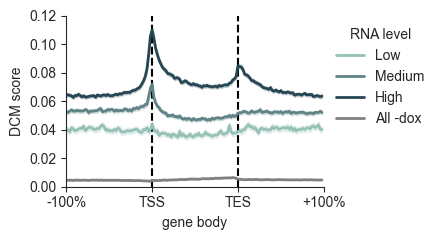

In [6]:
fig, ax = plt.subplots(1,1, figsize=(4.5, 2.5))

for level, level_color in zip(["Low", "Medium", "High"], level_colors):
    sns.lineplot(x="Bin", y="iPSC_dox", data=plot_df[plot_df["RNA level"] == level], 
                 zorder=2, ax=ax, color=level_color, linewidth=2, label=level)
sns.lineplot(x="Bin", y="iPSC_nodox", data=plot_df, zorder=2, ax=ax, color="gray", linewidth=2, label="All -dox")

ax.set(xlim=(0, n_bins*3), ylim=(0, 0.12), xlabel="gene body", ylabel="DCM score")
ax.axvline(n_bins, 0, 100, color="black", ls="--", zorder=1)
ax.axvline(n_bins*2, 0, 100, color="black", ls="--", zorder=1)
ax.set_xticks([0, n_bins, n_bins * 2, n_bins * 3])
ax.set_xticklabels(["-100%", "TSS", "TES", "+100%"])
ax.legend(frameon=False, bbox_to_anchor=(1, 1), loc="upper left", title="RNA level")

sns.despine()
plt.tight_layout()
plt.savefig(f"{output_dir}/Figure1e.svg", format="svg", bbox_inches="tight")
plt.show()

## Figure S2c. Profile plot iPSC -dox with RNA-seq categories

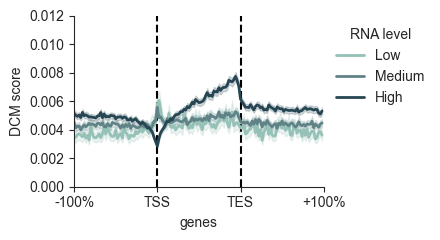

In [7]:
fig, ax = plt.subplots(1,1, figsize=(4.5, 2.5))

for level, level_color in zip(["Low", "Medium", "High"], level_colors):
    sns.lineplot(x="Bin", y="iPSC_nodox", data=plot_df[plot_df["RNA level"] == level], 
                 zorder=2, ax=ax, color=level_color, linewidth=2, label=level)

ax.set(xlim=(0, n_bins*3), ylim=(0, 0.012), xlabel="genes", ylabel="DCM score")
ax.axvline(n_bins, 0, 100, color="black", ls="--", zorder=1)
ax.axvline(n_bins*2, 0, 100, color="black", ls="--", zorder=1)
ax.set_xticks([0, n_bins, n_bins * 2, n_bins * 3])
ax.set_xticklabels(["-100%", "TSS", "TES", "+100%"])
ax.legend(frameon=False, bbox_to_anchor=(1, 1), loc="upper left", title="RNA level")

sns.despine()
plt.tight_layout()
plt.savefig(f"{output_dir}/SupplementalFigure2c.svg", format="svg", bbox_inches="tight")
plt.show()

## Figure S2e. Profile plots of iPSC -dox and DCM-NLS

In [8]:
meta_cols = ["GeneName", "GeneID", "Bin", "NrSites"]
samples = ["iPSC_nodox", "DCM-NLS"]

plot_df = bin_df[meta_cols + samples].copy()
display(plot_df)

,GeneName,GeneID,Bin,NrSites,iPSC_nodox,DCM-NLS
1,TSPAN6,ENSG00000000003,1,1,0.000000,0.0
2,TSPAN6,ENSG00000000003,10,1,0.000000,0.0
3,TSPAN6,ENSG00000000003,100,1,0.000000,0.0
4,TSPAN6,ENSG00000000003,101,2,0.009543,0.0
5,TSPAN6,ENSG00000000003,104,1,0.000000,0.0
...,...,...,...,...,...,...
3910760,.,ENSG00000291301,70,1,0.007859,0.0
3910761,.,ENSG00000291301,83,2,0.000000,0.0
3910762,.,ENSG00000291301,87,1,0.000000,0.0
3910763,.,ENSG00000291301,95,1,0.000000,0.0


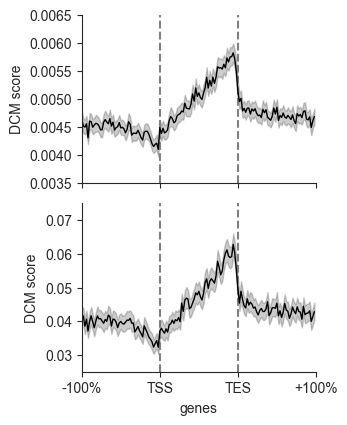

In [9]:
fig, axes = plt.subplots(2, 1, figsize=(3.5, 4.3), sharex=True)
axes = axes.flatten()

for i, sample in enumerate(samples):
    ax = axes[i]
    sns.lineplot(x="Bin", y=sample, data=plot_df, zorder=2, ax=ax, color="black", linewidth=1)
    
    ax.set(xlim=(0, n_bins*3), xlabel="genes", ylabel="DCM score")
    ax.axvline(n_bins, 0, 100, color="gray", ls="--", zorder=1)
    ax.axvline(n_bins*2, 0, 100, color="gray", ls="--", zorder=1)
    ax.set_xticks([0, n_bins, n_bins * 2, n_bins * 3])
    ax.set_xticklabels(["-100%", "TSS", "TES", "+100%"])

axes[0].set(ylim=(0.0035, 0.0065))
axes[1].set(ylim=(0.025, 0.075))

sns.despine()
plt.tight_layout()
plt.savefig(f"{output_dir}/SupplementalFigure2e.svg", format="svg", bbox_inches="tight")
plt.show()

## Figure S2f. Correlation between DCM-POLR2B and DCM-NLS profiles

In [10]:
meta_cols = ["GeneName", "GeneID", "Bin", "NrSites"]
samples = ["iPSC_nodox", "iPSC_dox", "DCM-NLS"]

plot_df = bin_df[meta_cols + samples].copy()
bin_means = plot_df.groupby("Bin")[samples].mean()
display(bin_means)

corr_df = bin_means.corr(method="pearson")
display(corr_df)

,iPSC_nodox,iPSC_dox,DCM-NLS
Bin,,,
0,0.004645,0.055846,0.041863
1,0.004523,0.055942,0.041497
2,0.004503,0.055928,0.038488
3,0.004563,0.056188,0.040603
4,0.004313,0.055369,0.037074
...,...,...,...
145,0.004632,0.055432,0.042425
146,0.004687,0.055181,0.043093
147,0.004498,0.055401,0.039962


,iPSC_nodox,iPSC_dox,DCM-NLS
iPSC_nodox,1.000000,-0.257010,0.975178
iPSC_dox,-0.257010,1.000000,-0.301404
DCM-NLS,0.975178,-0.301404,1.000000


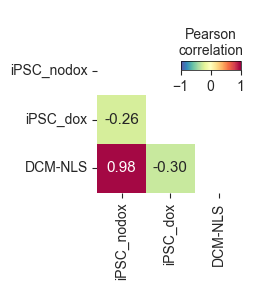

In [11]:
# Heatmap
mask = np.triu(np.ones_like(corr_df, dtype=bool)) # mask diagonal
g = sns.clustermap(corr_df, cmap="Spectral_r", annot=True, annot_kws={"size": 11}, fmt=".2f",
                   cbar_kws={"shrink": .8, "label": "Pearson\ncorrelation", "orientation": "horizontal"}, 
                   cbar_pos=(0.45, 0.75, 0.2, 0.03), vmin=-1, vmax=1,
                   figsize=(3,3), row_cluster=False, col_cluster=False, mask=mask)

# Ticks on left and bottom
g.ax_heatmap.tick_params(left=True, bottom=True, right=False, top=False,
                         labelleft=True, labelbottom=True, labelright=False, labeltop=False)

# Tweak color bar
g.cax.xaxis.set_label_position("top")
for spine in g.cax.spines.values():
    spine.set_edgecolor("black")
    spine.set_linewidth(0.5)

plt.savefig(f"{output_dir}/SupplementalFigure2f.svg", format="svg")
plt.show()

## Figure S3c: Profile plots of iPSC propagation experiment

In [12]:
meta_cols = ["GeneName", "GeneID", "Bin", "NrSites"]
samples = ["T0", "T24", "T48", "T72"]

plot_df = bin_df[meta_cols + samples].copy()

# # Remove extreme bins
# plot_df["Mean"] = plot_df[samples].mean(axis=1)
# max_norm = plot_df["Mean"].sample(10000).quantile(0.999)
# plot_df = plot_df[plot_df["Mean"] < max_norm]

display(plot_df)

,GeneName,GeneID,Bin,NrSites,T0,T24,T48,T72
1,TSPAN6,ENSG00000000003,1,1,0.0,0.0,0.0,0.0
2,TSPAN6,ENSG00000000003,10,1,0.0,0.0,0.0,0.0
3,TSPAN6,ENSG00000000003,100,1,0.0,0.0,0.0,0.0
4,TSPAN6,ENSG00000000003,101,2,0.0,0.0,0.0,0.0
5,TSPAN6,ENSG00000000003,104,1,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...
3910760,.,ENSG00000291301,70,1,0.0,0.0,0.0,0.0
3910761,.,ENSG00000291301,83,2,0.0,0.0,0.0,0.0
3910762,.,ENSG00000291301,87,1,0.0,0.0,0.0,0.0
3910763,.,ENSG00000291301,95,1,0.0,0.0,0.0,0.0


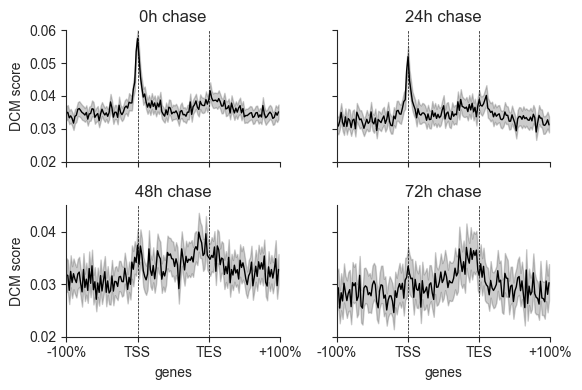

In [13]:
fig, axes = plt.subplots(2,2, figsize=(6, 4), sharex=True, sharey="row")
axes = axes.flatten()

for i, sample in enumerate(samples):
    ax = axes[i]
    sns.lineplot(x="Bin", y=sample, data=plot_df, zorder=2, ax=ax, color="black", linewidth=1)
    
    ax.set(xlim=(0, n_bins*3), ylim=(0.02, 0.06), xlabel="genes", ylabel="DCM score", title=f"{sample[1:]}h chase",
           xticks=[0, n_bins, n_bins * 2, n_bins * 3], xticklabels=["-100%", "TSS", "TES", "+100%"])

    # Vertical lines
    ax.axvline(n_bins, 0, 100, color="black", ls="--", zorder=1, linewidth=0.5)
    ax.axvline(n_bins*2, 0, 100, color="black", ls="--", zorder=1, linewidth=0.5)

axes[-1].set(ylim=(0.02, 0.045))

sns.despine()
plt.tight_layout()
plt.savefig(f"{output_dir}/SupplementalFigure3c.svg", format="svg", bbox_inches="tight")
plt.show()

## Figure S4d: Profile plots of PGT differentiation experiment

In [14]:
meta_cols = ["GeneName", "GeneID", "Bin", "NrSites"]
samples = ["iPSC_nodox", "iPSC_chase", "iPSC_dox", "DE_chase", "DE_dox", "PGT_chase"]

plot_df = bin_df[meta_cols + samples].copy()

# # Remove extreme bins
# plot_df["Mean"] = plot_df[samples].mean(axis=1)
# max_norm = plot_df["Mean"].sample(10000).quantile(0.999)
# plot_df = plot_df[plot_df["Mean"] < max_norm]

display(plot_df)

,GeneName,GeneID,Bin,NrSites,iPSC_nodox,iPSC_chase,iPSC_dox,DE_chase,DE_dox,PGT_chase
1,TSPAN6,ENSG00000000003,1,1,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
2,TSPAN6,ENSG00000000003,10,1,0.000000,0.000000,0.093232,0.000000,0.086487,0.136260
3,TSPAN6,ENSG00000000003,100,1,0.000000,0.055632,0.038349,0.062818,0.012467,0.000000
4,TSPAN6,ENSG00000000003,101,2,0.009543,0.051089,0.040529,0.088612,0.047330,0.000000
5,TSPAN6,ENSG00000000003,104,1,0.000000,0.000000,0.098173,0.000000,0.034669,0.000000
...,...,...,...,...,...,...,...,...,...,...
3910760,.,ENSG00000291301,70,1,0.007859,0.274883,0.026296,0.062818,0.067972,0.068902
3910761,.,ENSG00000291301,83,2,0.000000,0.000000,0.034532,0.000000,0.023665,0.000000
3910762,.,ENSG00000291301,87,1,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
3910763,.,ENSG00000291301,95,1,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000


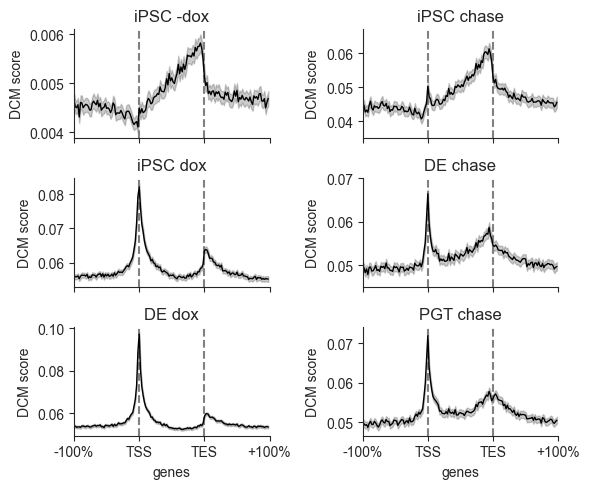

In [15]:
fig, axes = plt.subplots(3, 2, figsize=(6, 5), sharex=True)
axes = axes.flatten()

for i, label in enumerate(samples):
    ax = axes[i]
    sns.lineplot(x="Bin", y=label, data=plot_df, zorder=2, ax=ax, color="black", linewidth=1)
    ax.set(xlim=(0, n_bins*3), xlabel="genes", ylabel="DCM score", title=label.replace("_", " ").replace("no", "-"),
           xticks=[0, n_bins, n_bins * 2, n_bins * 3], xticklabels=["-100%", "TSS", "TES", "+100%"])
    
    ax.axvline(n_bins, 0, 100, color="gray", ls="--", zorder=1)
    ax.axvline(n_bins*2, 0, 100, color="gray", ls="--", zorder=1)

axes[1].set(ylim=(0.035, 0.067), yticks=[0.04, 0.05, 0.06])
axes[2].set(yticks=[0.06, 0.07, 0.08])
axes[3].set(ylim=(0.045, 0.07))
            
sns.despine()
plt.tight_layout()
plt.savefig(f"{output_dir}/SupplementalFigure4d.svg", format="svg", bbox_inches="tight")
plt.show()

# Figure 2b: TSS enrichment in PGT differentiation experiment

In [16]:
upstream_bins = [1, 2, 3]
tss_bins = [49, 50, 51]

# Table with gene per row
gene_df = plot_df.copy()
gene_df = gene_df[gene_df["Bin"].isin(tss_bins + upstream_bins)]
gene_df = gene_df.pivot_table(index=["GeneID", "GeneName"], columns="Bin", values=samples)
gene_df = gene_df.dropna()
for sample in samples:
    gene_df[f"FC_{sample}"] = np.log2(gene_df.loc[:, pd.IndexSlice[sample, tss_bins]].mean(axis=1) /
                                      gene_df.loc[:, pd.IndexSlice[sample, upstream_bins]].mean(axis=1))
display(gene_df)

/home/beatrice/.local/lib/python3.10/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: divide by zero encountered in log2
  result = getattr(ufunc, method)(*inputs, **kwargs)
/home/beatrice/.local/lib/python3.10/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: divide by zero encountered in log2
  result = getattr(ufunc, method)(*inputs, **kwargs)
/home/beatrice/.local/lib/python3.10/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: divide by zero encountered in log2
  result = getattr(ufunc, method)(*inputs, **kwargs)
/home/beatrice/.local/lib/python3.10/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: divide by zero encountered in log2
  result = getattr(ufunc, method)(*inputs, **kwargs)
/home/beatrice/.local/lib/python3.10/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: divide by zero encountered in log2
  result = getattr(ufunc, method)(*inputs, **kwargs)
/home/beatrice/.local/lib/python3.10/site-packages/pandas/core/arraylike.py

DE_chase                                          \
Bin                                 1         2         3        49        50   
GeneID          GeneName                                                        
ENSG00000000460 C1orf112     0.054411  0.020056  0.038964  0.104603  0.060899   
ENSG00000000938 FGR          0.044810  0.014553  0.082221  0.000000  0.038807   
ENSG00000001036 FUCA2        0.000000  0.000000  0.060804  0.060804  0.108581   
ENSG00000001084 GCLC         0.135581  0.053809  0.033651  0.000000  0.040471   
ENSG00000001167 NFYA         0.061378  0.058211  0.019404  0.000000  0.077187   
...                               ...       ...       ...       ...       ...   
ENSG00000291266 SMG1P5       0.030641  0.053278  0.071884  0.054590  0.049449   
ENSG00000291280 ANKRD20A11P  0.014553  0.039671  0.118150  0.000000  0.231234   
ENSG00000291287 .            0.000000  0.000000  0.000000  0.181939  0.051869   
ENSG00000291293 .            0.000000  0.024322  0.000000  0.008974  0.000000   
ENSG00000291299 .            0.049957  0.113268  0.030085  0.065885  0.038148   

                                         DE_dox                                \
Bin                                51         1         2         3        49   
GeneID          GeneName                                                        
ENSG00000000460 C1orf112     0.116077  0.069182  0.060381  0.102360  0.041082   
ENSG00000000938 FGR          0.024724  0.082293  0.048794  0.031945  0.000000   
ENSG00000001036 FUCA2        0.179818  0.028829  0.016651  0.045770  0.153286   
ENSG00000001084 GCLC         0.000000  0.053710  0.115398  0.059711  0.039152   
ENSG00000001167 NFYA         0.020939  0.032626  0.074020  0.003700  0.071287   
...                               ...       ...       ...       ...       ...   
ENSG00000291266 SMG1P5       0.123621  0.079000  0.138624  0.150248  0.109488   
ENSG00000291280 ANKRD20A11P  0.060804  0.026831  0.079795  0.042264  0.000000   
ENSG00000291287 .            0.139760  0.012467  0.000000  0.012467  0.084996   
ENSG00000291293 .            0.019404  0.006282  0.046320  0.000000  0.024237   
ENSG00000291299 .            0.131070  0.055672  0.122155  0.067687  0.035664   

                             ... iPSC_nodox                                \
Bin                          ...          3        49        50        51   
GeneID          GeneName     ...                                            
ENSG00000000460 C1orf112     ...   0.005403  0.014602  0.003105  0.019817   
ENSG00000000938 FGR          ...   0.005239  0.009543  0.000000  0.003951   
ENSG00000001036 FUCA2        ...   0.000000  0.000000  0.014659  0.000000   
ENSG00000001084 GCLC         ...   0.003142  0.003144  0.000000  0.000000   
ENSG00000001167 NFYA         ...   0.020421  0.000000  0.001459  0.000000   
...                          ...        ...       ...       ...       ...   
ENSG00000291266 SMG1P5       ...   0.012490  0.002807  0.003951  0.000000   
ENSG00000291280 ANKRD20A11P  ...   0.000000  0.010211  0.019116  0.000000   
ENSG00000291287 .            ...   0.000000  0.021665  0.003368  0.002620   
ENSG00000291293 .            ...   0.000000  0.001363  0.000000  0.002620   
ENSG00000291299 .            ...   0.001975  0.001643  0.000605  0.016976   

                            FC_iPSC_nodox FC_iPSC_chase FC_iPSC_dox  \
Bin                                                                   
GeneID          GeneName                                              
ENSG00000000460 C1orf112         1.734936      3.472140   -1.564727   
ENSG00000000938 FGR              0.823474      0.940020   -0.411406   
ENSG00000001036 FUCA2                 inf      1.891424    1.369940   
ENSG00000001084 GCLC            -1.202486     -0.664842   -0.629155   
ENSG00000001167 NFYA            -3.807355      0.600282    1.093155   
...                                   ...           ...         ...   
ENSG00000291266 SMG1P5          -1.086095

In [17]:
# Statistics
results = {}
for sample in samples[1:]:
    stat_df = gene_df[[f"FC_{sample}", f"FC_iPSC_nodox"]].replace([float("inf"), -float("inf")], pd.NA).dropna().astype(float)
    stat, p = scipy.stats.wilcoxon(stat_df[f"FC_{sample}"], stat_df[f"FC_iPSC_nodox"], alternative="two-sided")
    results[sample] = {"stat": stat, "pval": p}
results_df = pd.DataFrame(results).T
results_df["padj"] = multipletests(results_df["pval"], method="fdr_bh")[1]
print(results_df)

                  stat           pval           padj
iPSC_chase  20418224.0   1.435264e-95   1.435264e-95
iPSC_dox    20670887.0  1.852960e-260  3.088266e-260
DE_chase    20957033.0  2.272357e-206  2.840447e-206
DE_dox      18306696.0   0.000000e+00   0.000000e+00
PGT_chase   19017771.0   0.000000e+00   0.000000e+00


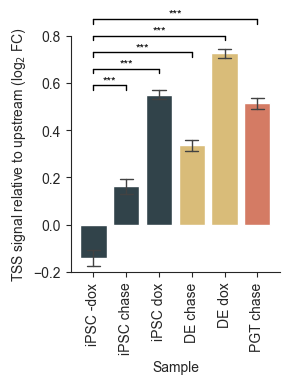

In [18]:
# Convert to long format for seaborn
fc_df = gene_df[[f"FC_{sample}" for sample in samples]].melt(var_name="Sample", value_name="FoldChange").dropna()
fc_df = fc_df.replace([float("inf"), -float("inf")], pd.NA).dropna() #remove infinite values

# Plot
plt.figure(figsize=(3, 4))
sns.barplot(data=fc_df, x="Sample", y="FoldChange", hue="Sample", errorbar=("ci", 95), capsize=0.4, err_kws={"linewidth": 1},
            palette=["#2d454e"]*3 + ["#e9c369"]*2 + ["#e77051"])
plt.xticks(ticks=range(len(samples)), labels=[sample.replace("_", " ").replace("no", "-") for sample in samples], rotation=90)
plt.ylim(-0.2, 0.8)
plt.ylabel("TSS signal relative to upstream (log$_2$ FC)")

# Statistics
for y1, y2, x1, x2, label in [[0.57, 0.59, 0, 1, "***"], [0.64, 0.66, 0, 2, "***"], [0.71, 0.73, 0, 3, "***"],
                             [0.78, 0.80, 0, 4, "***"], [0.85, 0.87, 0, 5, "***"]]:
    plt.plot((x1, x1), (y1, y2), color="black", linewidth=1, clip_on=False)
    plt.plot((x2, x2), (y1, y2), color="black", linewidth=1, clip_on=False)
    plt.plot((x1, x2), (y2, y2), color="black", linewidth=1, clip_on=False)
    plt.text((x1+x2)/2, y2, label, ha="center", va="bottom", color="black", fontsize="small")

sns.despine()
plt.tight_layout()
plt.savefig(f"{output_dir}/Figure2b.svg", format="svg")
plt.show()